# Retail & Marketing Analytics Project
## Notebook 04: Customer Segmentation and Advanced Analytics

| | |
|---|---|
| **Project** | Retail & Marketing Analytics - Customer Segmentation & Sales Optimization |
| **Notebook** | 04 - Customer Segmentation and Advanced Analytics |
| **Author** | Ayush Kumar Singh |
| **Date** | 13th July 2026 |

### Objectives
- RFM Analysis (Recency, Frequency, Monetary)
- K-Means Clustering for customer segmentation
- Cluster profiling and characterization
- Market Basket Analysis
- Cohort Analysis
- Customer Lifetime Value (CLV) calculation


## 1. Import Libraries and Load Data
Import data science, machine learning (scikit-learn), and market basket analysis (mlxtend, optional) libraries, then load the cleaned dataset from Notebook 02.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Market Basket Analysis
# pip install mlxtend
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MBA_AVAILABLE = True
except ImportError:
    MBA_AVAILABLE = False
    print("mlxtend not installed. Run: pip install mlxtend")

from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Project Root
PROJECT_ROOT = Path.cwd().parent

# Data folders
RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

# Output folders
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
REPORTS = OUTPUTS / "reports"

# Load cleaned data
df = pd.read_csv(PROCESSED_DATA / "cleaned_retail_sales.csv")
df['Order_Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01')
# Ship_Date doesn't exist in this dataset, so we'll skip it or create it if needed
# df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])  # Column not available in this dataset

print("="*80)
print("CUSTOMER SEGMENTATION AND ADVANCED ANALYTICS")
print("="*80)
print(f"\nDataset Shape: {df.shape}")

CUSTOMER SEGMENTATION AND ADVANCED ANALYTICS

Dataset Shape: (10000, 45)


## 2. RFM Analysis (Recency, Frequency, Monetary)
Compute Recency, Frequency, and Monetary metrics per customer, convert them into 1-5 scores using quintiles, combine them into an RFM score, and assign each customer to a business-friendly segment (Champions, Loyal Customers, At Risk, Lost, etc.).

In [2]:
print("\n" + "="*80)
print("RFM ANALYSIS")
print("="*80)

# Set analysis date (day after last transaction)
analysis_date = df['Order_Date'].max() + timedelta(days=1)
print(f"\nAnalysis Date: {analysis_date.date()}")

# Calculate RFM metrics for each customer
# Use SUPPLIER as a customer proxy because Customer_ID is not present in this dataset
customer_col = 'Customer_ID' if 'Customer_ID' in df.columns else 'SUPPLIER'

# Build a monetary value from the available sales columns
sales_cols = [c for c in ['Sales','RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'] if c in df.columns]
df['Monetary_Value'] = df[sales_cols].fillna(0).sum(axis=1) if sales_cols else 0

rfm = df.groupby(customer_col).agg(
    Recency=('Order_Date', lambda x: (analysis_date - x.max()).days),
    Frequency=('Order_Date', 'size'),
    Monetary=('Monetary_Value', 'sum')
).reset_index().rename(columns={customer_col: 'Customer_ID'})

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

print(f"\nRFM Metrics Calculated for {len(rfm):,} customers")
print("\nRFM Summary Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())


RFM ANALYSIS

Analysis Date: 2023-02-02

RFM Metrics Calculated for 1,986 customers

RFM Summary Statistics:
           Recency    Frequency     Monetary
count  1986.000000  1986.000000  1986.000000
mean     76.443102     5.035247   543.137452
std      77.612751     2.256983   282.191515
min       1.000000     1.000000    13.521954
25%      32.000000     3.000000   330.710807
50%      63.000000     5.000000   516.372006
75%     124.000000     6.000000   716.082448
max     397.000000    14.000000  1706.776827


In [3]:
# Create RFM scores (1-5 scale, where 5 is best)
print("\nCreating RFM Scores...")

# Recency Score (lower is better, so reverse)
# Recency Score (lower is better, so reverse)
r_bins = pd.qcut(rfm['Recency'].rank(method='first'), q=5, labels=False, duplicates='drop')
rfm['R_Score'] = r_bins.max() - r_bins + 1

# Frequency Score (higher is better)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5,
                         labels=[1, 2, 3, 4, 5], duplicates='drop')

# Monetary Score (higher is better)
# Monetary Score (higher is better) - robust to ties / constant values
if rfm['Monetary'].nunique() == 1:
    # All customers have same monetary value (e.g., zeros) -> assign lowest score
    rfm['M_Score'] = 1
else:
    m_bins = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=False, duplicates='drop')
    rfm['M_Score'] = (m_bins + 1).astype(int)

# Combined RFM Score
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) +
                    rfm['F_Score'].astype(str) +
                    rfm['M_Score'].astype(str))

# Numeric RFM Score (average)
rfm['RFM_Score_Numeric'] = (rfm['R_Score'].astype(int) +
                            rfm['F_Score'].astype(int) +
                            rfm['M_Score'].astype(int)) / 3

print("RFM Scores Created")


Creating RFM Scores...
RFM Scores Created


In [4]:
# Customer Segmentation based on RFM
def segment_customers(row):
    """Segment customers based on RFM scores"""
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])

    # Champions: Best customers
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    # Loyal Customers: Buy regularly
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    # Potential Loyalists: Recent customers with potential
    elif r >= 4 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    # New Customers: Recent first-time buyers
    elif r >= 3 and f <= 2:
        return 'New Customers'
    # Promising: Recent but low spenders
    elif r >= 3 and m <= 2:
        return 'Promising'
    # Need Attention: Above average recency, frequency, and monetary
    elif r == 3 and f == 3 and m == 3:
        return 'Need Attention'
    # About to Sleep: Below average engagement
    elif r <= 2 and f <= 2:
        return 'About to Sleep'
    # At Risk: Used to be good, now declining
    elif r <= 2 and f >= 3:
        return 'At Risk'
    # Can't Lose Them: Were best customers but churning
    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    # Lost: Long time since purchase
    elif r == 1:
        return 'Lost'
    else:
        return 'Others'

rfm['Customer_Segment'] = rfm.apply(segment_customers, axis=1)

print("\nCustomer Segmentation Complete:")
print(rfm['Customer_Segment'].value_counts())


Customer Segmentation Complete:
Customer_Segment
About to Sleep         440
Loyal Customers        414
At Risk                354
Champions              335
New Customers          289
Promising               88
Potential Loyalists     66
Name: count, dtype: int64


In [5]:
# Visualize RFM segments
fig = px.pie(rfm['Customer_Segment'].value_counts().reset_index(),
             values='count',
             names='Customer_Segment',
             title='Customer Distribution by RFM Segments',
             hole=0.4,
             color_discrete_sequence=px.colors.qualitative.Set3)
FIGURES.mkdir(parents=True, exist_ok=True)
fig.write_html(FIGURES / '17_rfm_segments.html')
print("Saved: 17_rfm_segments.html")

Saved: 17_rfm_segments.html


In [6]:
# RFM Summary by Segment
rfm_summary = rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer_ID': 'count'
}).round(2)
rfm_summary.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
rfm_summary['Revenue_Contribution'] = (rfm.groupby('Customer_Segment')['Monetary'].sum() /
                                        rfm['Monetary'].sum() * 100).round(2)
rfm_summary = rfm_summary.sort_values('Revenue_Contribution', ascending=False)

print("\nRFM Segment Summary:")
print(rfm_summary)

# Save RFM analysis
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)
rfm.to_csv(PROCESSED_DATA / 'rfm_analysis.csv', index=False)
print("\nRFM analysis saved to: data/processed/rfm_analysis.csv")


RFM Segment Summary:
                     Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Count  \
Customer_Segment                                                                
Loyal Customers            36.57           6.30        694.65             414   
Champions                  13.40           7.69        856.37             335   
At Risk                   121.77           5.81        624.85             354   
About to Sleep            172.84           2.74        294.56             440   
New Customers              33.18           2.98        292.96             289   
Potential Loyalists        19.32           3.85        548.78              66   
Promising                  24.60           5.02        369.47              88   

                     Revenue_Contribution  
Customer_Segment                           
Loyal Customers                     26.66  
Champions                           26.60  
At Risk                             20.51  
About to Sleep              

## 3. K-Means Clustering
Standardize the RFM features, determine the optimal number of clusters using the Elbow Method, Silhouette Score, and Davies-Bouldin Index, then fit the final K-Means model.

In [7]:
print("\n" + "="*80)
print("K-MEANS CLUSTERING")
print("="*80)

# Prepare data for clustering
clustering_features = ['Recency', 'Frequency', 'Monetary']
X = rfm[clustering_features].values

print(f"\nFeatures for clustering: {clustering_features}")
print(f"Data shape: {X.shape}")

# Standardize features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized")


K-MEANS CLUSTERING

Features for clustering: ['Recency', 'Frequency', 'Monetary']
Data shape: (1986, 3)
Features standardized


In [8]:
# Determine optimal number of clusters using Elbow Method and Silhouette Score
print("\nDetermining Optimal Number of Clusters...")

inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))


Determining Optimal Number of Clusters...


Saved: 18_optimal_clusters.png


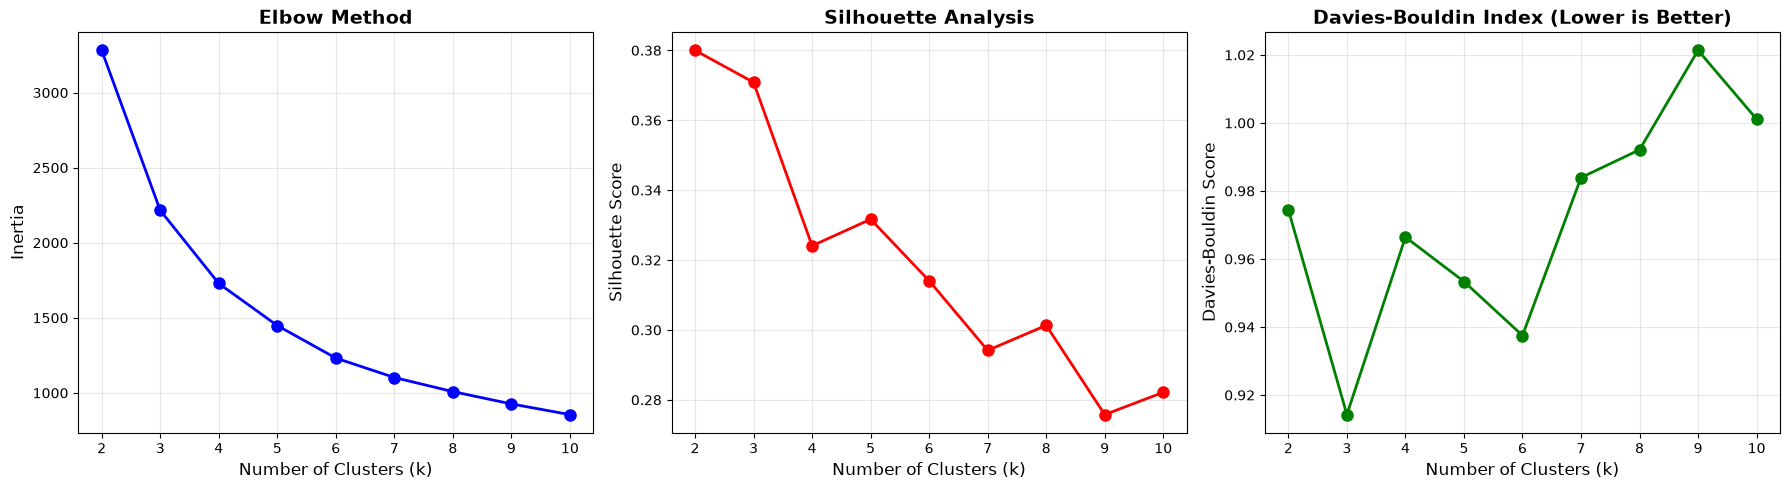


Clustering Evaluation Metrics:
k=2: Inertia=3281.80, Silhouette=0.3800, Davies-Bouldin=0.9745
k=3: Inertia=2215.76, Silhouette=0.3709, Davies-Bouldin=0.9142
k=4: Inertia=1728.95, Silhouette=0.3241, Davies-Bouldin=0.9664
k=5: Inertia=1448.46, Silhouette=0.3317, Davies-Bouldin=0.9534
k=6: Inertia=1231.88, Silhouette=0.3141, Davies-Bouldin=0.9375
k=7: Inertia=1102.49, Silhouette=0.2942, Davies-Bouldin=0.9839
k=8: Inertia=1008.65, Silhouette=0.3013, Davies-Bouldin=0.9921
k=9: Inertia=926.45, Silhouette=0.2758, Davies-Bouldin=1.0214
k=10: Inertia=855.31, Silhouette=0.2822, Davies-Bouldin=1.0011


In [9]:
# Plot evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin Score (lower is better)
axes[2].plot(K_range, davies_bouldin_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
FIGURES.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES / '18_optimal_clusters.png', dpi=300, bbox_inches='tight')
print("Saved: 18_optimal_clusters.png")
plt.show()

print("\nClustering Evaluation Metrics:")
for k, inertia, sil_score, db_score in zip(K_range, inertias, silhouette_scores, davies_bouldin_scores):
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}")

In [10]:
# Choose optimal k (typically where silhouette score is highest and elbow occurs)
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal k based on Silhouette Score: {optimal_k}")

# Apply K-Means with optimal k
print(f"\nApplying K-Means with k={optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Clustering complete!")
print(f"  - Silhouette Score: {silhouette_score(X_scaled, rfm['Cluster']):.4f}")
print(f"  - Davies-Bouldin Score: {davies_bouldin_score(X_scaled, rfm['Cluster']):.4f}")


Optimal k based on Silhouette Score: 2

Applying K-Means with k=2...
Clustering complete!
  - Silhouette Score: 0.3800
  - Davies-Bouldin Score: 0.9745


## 4. Cluster Profiling and Characterization
Summarize each cluster's average Recency/Frequency/Monetary values, assign meaningful business names (VIP Customers, High Value, Potential, At Risk), and print a detailed profile with recommended marketing actions for each.

In [11]:
print("\n" + "="*80)
print("CLUSTER PROFILING AND CHARACTERIZATION")
print("="*80)

# Cluster statistics
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'std'],
    'Frequency': ['mean', 'std'],
    'Monetary': ['mean', 'std'],
    'Customer_ID': 'count'
}).round(2)

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.rename(columns={'Customer_ID_count': 'Customer_Count'})
cluster_summary['Customer_Percentage'] = (cluster_summary['Customer_Count'] /
                                          cluster_summary['Customer_Count'].sum() * 100).round(2)

print("\nCluster Summary Statistics:")
print(cluster_summary)


CLUSTER PROFILING AND CHARACTERIZATION

Cluster Summary Statistics:
         Recency_mean  Recency_std  Frequency_mean  Frequency_std  \
Cluster                                                             
0               40.45        41.04            6.90           1.66   
1              107.64        87.70            3.42           1.23   

         Monetary_mean  Monetary_std  Customer_Count  Customer_Percentage  
Cluster                                                                    
0               772.18        218.28             922                46.42  
1               344.66        149.97            1064                53.58  


In [12]:
# Name clusters based on characteristics
def name_cluster_characteristics(cluster_data):
    """Assign meaningful names to clusters"""
    names = {}

    for cluster_id in cluster_data.index:
        r_mean = cluster_data.loc[cluster_id, 'Recency_mean']
        f_mean = cluster_data.loc[cluster_id, 'Frequency_mean']
        m_mean = cluster_data.loc[cluster_id, 'Monetary_mean']

        # Define thresholds (adjust based on your data)
        r_threshold = cluster_data['Recency_mean'].median()
        f_threshold = cluster_data['Frequency_mean'].median()
        m_threshold = cluster_data['Monetary_mean'].median()

        if r_mean < r_threshold and f_mean > f_threshold and m_mean > m_threshold:
            names[cluster_id] = 'VIP Customers'
        elif f_mean > f_threshold and m_mean > m_threshold:
            names[cluster_id] = 'High Value'
        elif r_mean < r_threshold and f_mean <= f_threshold:
            names[cluster_id] = 'Potential'
        else:
            names[cluster_id] = 'At Risk'

    return names

cluster_names = name_cluster_characteristics(cluster_summary)
rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)

print("\nCluster Names:")
for cluster_id, name in cluster_names.items():
    count = cluster_summary.loc[cluster_id, 'Customer_Count']
    pct = cluster_summary.loc[cluster_id, 'Customer_Percentage']
    print(f"  Cluster {cluster_id}: {name} ({count:.0f} customers, {pct:.1f}%)")


Cluster Names:
  Cluster 0: VIP Customers (922 customers, 46.4%)
  Cluster 1: At Risk (1064 customers, 53.6%)


In [13]:
# Detailed profiling report
print("\n" + "="*80)
print("DETAILED CLUSTER PROFILES")
print("="*80)

for cluster_id, cluster_name in cluster_names.items():
    cluster_data = rfm[rfm['Cluster'] == cluster_id]
    total_revenue = cluster_data['Monetary'].sum()
    revenue_share = (total_revenue / rfm['Monetary'].sum() * 100)

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}: {cluster_name}")
    print(f"{'='*60}")
    print(f"Size: {len(cluster_data):,} customers ({len(cluster_data)/len(rfm)*100:.1f}%)")
    print(f"\nRFM Metrics:")
    print(f"  - Avg Recency: {cluster_data['Recency'].mean():.1f} days")
    print(f"  - Avg Frequency: {cluster_data['Frequency'].mean():.1f} orders")
    print(f"  - Avg Monetary: ${cluster_data['Monetary'].mean():,.2f}")
    print(f"  - Total Revenue: ${total_revenue:,.2f} ({revenue_share:.1f}% of total)")

    print(f"\nRecommended Marketing Actions:")
    if cluster_name == 'VIP Customers':
        print("  - Exclusive rewards and early access to new products")
        print("  - Personalized communication and dedicated support")
        print("  - Premium tier membership programs")
        print("  - Referral incentives")
    elif cluster_name == 'High Value':
        print("  - Loyalty programs with tiered benefits")
        print("  - Cross-sell and upsell campaigns")
        print("  - Regular engagement through email marketing")
        print("  - Special occasion offers")
    elif cluster_name == 'Potential':
        print("  - Nurture with targeted promotions")
        print("  - Product recommendations based on browsing")
        print("  - Time-limited offers to encourage repeat purchase")
        print("  - Educational content about products")
    else:  # At Risk
        print("  - Win-back campaigns with special discounts")
        print("  - Survey to understand reasons for churn")
        print("  - Re-engagement through personalized content")
        print("  - Abandoned cart reminders")


DETAILED CLUSTER PROFILES

CLUSTER 0: VIP Customers
Size: 922 customers (46.4%)

RFM Metrics:
  - Avg Recency: 40.4 days
  - Avg Frequency: 6.9 orders
  - Avg Monetary: $772.18
  - Total Revenue: $711,947.89 (66.0% of total)

Recommended Marketing Actions:
  - Exclusive rewards and early access to new products
  - Personalized communication and dedicated support
  - Premium tier membership programs
  - Referral incentives

CLUSTER 1: At Risk
Size: 1,064 customers (53.6%)

RFM Metrics:
  - Avg Recency: 107.6 days
  - Avg Frequency: 3.4 orders
  - Avg Monetary: $344.66
  - Total Revenue: $366,723.09 (34.0% of total)

Recommended Marketing Actions:
  - Win-back campaigns with special discounts
  - Survey to understand reasons for churn
  - Re-engagement through personalized content
  - Abandoned cart reminders


In [14]:
# Save cluster profiling
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)
rfm.to_csv(PROCESSED_DATA / 'customer_segments.csv', index=False)
print("\nCustomer segments saved to: data/processed/customer_segments.csv")


Customer segments saved to: data/processed/customer_segments.csv


## 5. Cluster Visualization
Reduce the RFM feature space to 2D with PCA for a scatter plot of segments, view the segments directly in 3D RFM space, and compare customer count vs. revenue contribution by segment.

In [15]:
print("\n" + "="*80)
print("CLUSTER VISUALIZATION")
print("="*80)

# 5.1 PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

rfm['PCA1'] = X_pca[:, 0]
rfm['PCA2'] = X_pca[:, 1]

explained_var = pca.explained_variance_ratio_
print(f"\nPCA Explained Variance:")
print(f"  PC1: {explained_var[0]*100:.2f}%")
print(f"  PC2: {explained_var[1]*100:.2f}%")
print(f"  Total: {sum(explained_var)*100:.2f}%")

# 2D Scatter plot
fig = px.scatter(rfm, x='PCA1', y='PCA2', color='Cluster_Name',
                 title='Customer Segments Visualization (PCA)',
                 labels={'PCA1': f'PC1 ({explained_var[0]:.2%} variance)',
                         'PCA2': f'PC2 ({explained_var[1]:.2%} variance)'},
                 hover_data=['Recency', 'Frequency', 'Monetary', 'Customer_ID'],
                 color_discrete_sequence=px.colors.qualitative.Set2)
FIGURES.mkdir(parents=True, exist_ok=True)
fig.write_html(FIGURES / '19_customer_segments_pca.html')
print("Saved: 19_customer_segments_pca.html")


CLUSTER VISUALIZATION

PCA Explained Variance:
  PC1: 70.71%
  PC2: 24.53%
  Total: 95.24%
Saved: 19_customer_segments_pca.html


In [16]:
# 5.2 3D visualization in RFM space
fig = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary',
                    color='Cluster_Name',
                    title='Customer Segments in RFM Space',
                    labels={'Recency': 'Recency (days)',
                            'Frequency': 'Frequency (orders)',
                            'Monetary': 'Monetary ($)'},
                    hover_data=['Customer_ID'],
                    color_discrete_sequence=px.colors.qualitative.Pastel)
FIGURES.mkdir(parents=True, exist_ok=True)
fig.write_html(FIGURES / '20_customer_segments_3d.html')
print("Saved: 20_customer_segments_3d.html")

Saved: 20_customer_segments_3d.html


In [17]:
# 5.3 Segment size and revenue contribution
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Customer Count by Segment', 'Revenue by Segment'),
                    specs=[[{'type': 'bar'}, {'type': 'bar'}]])

segment_counts = rfm['Cluster_Name'].value_counts()
segment_revenue = rfm.groupby('Cluster_Name')['Monetary'].sum().sort_values(ascending=False)

fig.add_trace(go.Bar(x=segment_counts.index, y=segment_counts.values,
                     name='Customers', marker_color='lightblue'), row=1, col=1)
fig.add_trace(go.Bar(x=segment_revenue.index, y=segment_revenue.values,
                     name='Revenue', marker_color='lightcoral'), row=1, col=2)

fig.update_xaxes(title_text="Segment", row=1, col=1)
fig.update_xaxes(title_text="Segment", row=1, col=2)
fig.update_yaxes(title_text="Number of Customers", row=1, col=1)
fig.update_yaxes(title_text="Total Revenue ($)", row=1, col=2)
fig.update_layout(height=500, showlegend=False, title_text="Segment Distribution")

FIGURES.mkdir(parents=True, exist_ok=True)
fig.write_html(FIGURES / '21_segment_distribution.html')
print("Saved: 21_segment_distribution.html")

Saved: 21_segment_distribution.html


## 6. Market Basket Analysis (Optional)
If `mlxtend` is available and a `Product_ID` column exists, find frequently co-purchased product combinations using the Apriori algorithm, generate association rules, and visualize support vs. confidence.

In [18]:
if MBA_AVAILABLE and 'Product_ID' in df.columns:
    print("\n" + "="*80)
    print("MARKET BASKET ANALYSIS")
    print("="*80)

    try:
        # Prepare transaction data
        transactions = df.groupby('Order_ID')['Product_ID'].apply(list).tolist()
        print(f"\nTotal Transactions: {len(transactions):,}")

        # Encode transactions
        te = TransactionEncoder()
        te_ary = te.fit(transactions).transform(transactions)
        df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

        # Find frequent itemsets
        print("Finding frequent itemsets...")
        frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
        print(f"Found {len(frequent_itemsets)} frequent itemsets")

        # Generate association rules
        print("Generating association rules...")
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
        rules = rules.sort_values('lift', ascending=False)

        print(f"Generated {len(rules)} association rules")
        print("\nTop 10 Association Rules:")
        print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

        # Visualize rules
        fig = px.scatter(rules.head(50), x='support', y='confidence',
                         size='lift', color='lift',
                         title='Association Rules: Support vs Confidence (Top 50)',
                         labels={'support': 'Support', 'confidence': 'Confidence'},
                         color_continuous_scale='viridis',
                         hover_data=['antecedents', 'consequents'])
        fig.write_html('outputs/figures/22_association_rules.html')
        print("Saved: 22_association_rules.html")

        # Save rules
        rules.to_csv('outputs/reports/market_basket_rules.csv', index=False)
        print("Rules saved to: outputs/reports/market_basket_rules.csv")

    except Exception as e:
        print(f"Market Basket Analysis skipped: {e}")
else:
    print("\nMarket Basket Analysis skipped (mlxtend not installed or Product_ID not available)")


MARKET BASKET ANALYSIS

Total Transactions: 10,000
Finding frequent itemsets...
Found 0 frequent itemsets
Generating association rules...
Market Basket Analysis skipped: The input DataFrame `df` containing the frequent itemsets is empty.


## 7. Cohort Analysis
Group customers into monthly cohorts by their first purchase date, calculate how many months have passed since that first purchase for each transaction, and build a retention-rate heatmap showing how each cohort behaves over time.

In [19]:
print("\n" + "="*80)
print("COHORT ANALYSIS")
print("="*80)

# Create cohort data
df_cohort = df.copy()
df_cohort['Order_Month'] = df_cohort['Order_Date'].dt.to_period('M')
customer_col = 'Customer_ID' if 'Customer_ID' in df_cohort.columns else 'SUPPLIER'
df_cohort['Customer_ID'] = df_cohort[customer_col]
df_cohort['Cohort'] = df_cohort.groupby('Customer_ID')['Order_Date'].transform('min').dt.to_period('M')

# Calculate cohort index (months since first purchase)
def get_cohort_period(df):
    df['Cohort_Index'] = (df['Order_Month'] - df['Cohort']).apply(lambda x: x.n)
    return df

def get_cohort_period(df):
    # Calculate months since first purchase in a robust way
    df['Cohort_Index'] = (
        (df['Order_Month'].dt.year - df['Cohort'].dt.year) * 12
        + (df['Order_Month'].dt.month - df['Cohort'].dt.month)
        + 1
    )
    return df

df_cohort = get_cohort_period(df_cohort)

# Cohort size
cohort_size = df_cohort.groupby('Cohort')['Customer_ID'].nunique()
print(f"\nTotal Cohorts: {len(cohort_size)}")
print("\nCohort Sizes:")
print(cohort_size.tail())


COHORT ANALYSIS

Total Cohorts: 14

Cohort Sizes:
Cohort
2022-10    27
2022-11    25
2022-12     9
2023-01    11
2023-02     6
Freq: M, Name: Customer_ID, dtype: int64


In [20]:
# Retention matrix
retention = df_cohort.groupby(['Cohort', 'Cohort_Index'])['Customer_ID'].nunique().reset_index()
retention_matrix = retention.pivot(index='Cohort', columns='Cohort_Index', values='Customer_ID')

# Calculate retention rate
retention_rate = retention_matrix.divide(cohort_size, axis=0) * 100

print("\nCohort Retention Rates (%):")
print(retention_rate.head())


Cohort Retention Rates (%):
Cohort_Index     1          2          3          4          5          6   \
Cohort                                                                       
2022-01       100.0  26.821192  31.622517  29.139073  31.125828  32.615894   
2022-02       100.0  30.886076  28.860759  28.354430  35.443038  29.620253   
2022-03       100.0  31.615120  32.302405  30.927835  32.646048  28.522337   
2022-04       100.0  32.352941  24.019608  29.901961  31.372549  27.450980   
2022-05       100.0  34.074074  28.888889  32.592593  25.925926  34.074074   

Cohort_Index         7          8          9          10         11  \
Cohort                                                                
2022-01       30.463576  31.291391  26.324503  31.953642  29.635762   
2022-02       30.379747  34.683544  31.645570  33.670886  30.886076   
2022-03       32.302405  25.085911  24.054983  31.271478  35.395189   
2022-04       29.901961  30.392157  32.352941  32.843137  22.549020  

Saved: 23_cohort_retention.png


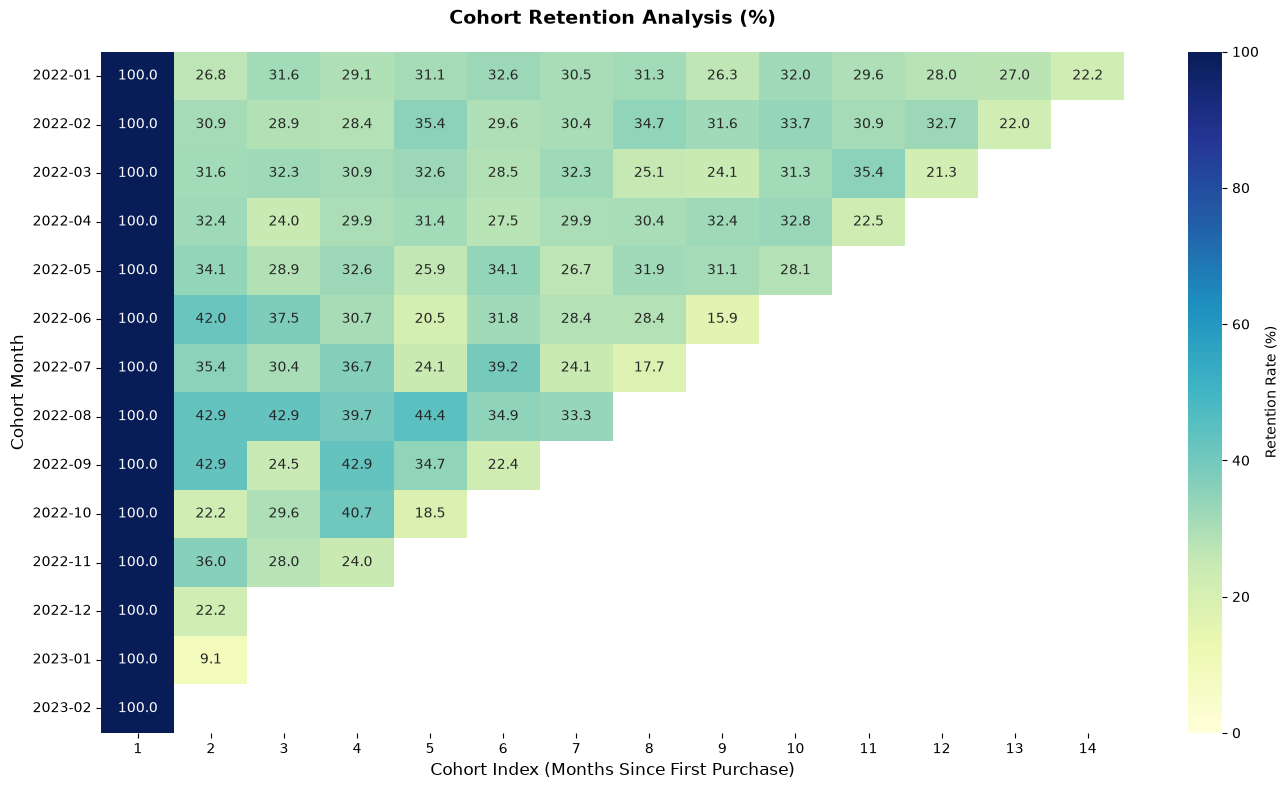

Cohort data saved to: outputs/reports/cohort_retention.csv


In [21]:
# Visualize cohort retention
plt.figure(figsize=(14, 8))
sns.heatmap(retention_rate, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': 'Retention Rate (%)'}, vmin=0, vmax=100)
plt.title('Cohort Retention Analysis (%)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cohort Index (Months Since First Purchase)', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
FIGURES.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES / '23_cohort_retention.png', dpi=300, bbox_inches='tight')
print("Saved: 23_cohort_retention.png")
plt.show()

# Save cohort data
REPORTS.mkdir(parents=True, exist_ok=True)
retention_rate.to_csv(REPORTS / 'cohort_retention.csv')
print("Cohort data saved to: outputs/reports/cohort_retention.csv")

## 8. Customer Lifetime Value (CLV)
Calculate a simple CLV per customer as Average Order Value x Purchase Frequency x Assumed Lifespan (3 years), bucket customers into CLV tiers, visualize the distribution, and save the results.

In [22]:
print("\n" + "="*80)
print("CUSTOMER LIFETIME VALUE (CLV) CALCULATION")
print("="*80)

# Calculate CLV components
customer_metrics = df.groupby(customer_col).agg(
    Total_Revenue=('Monetary_Value', 'sum'),
    Order_Count=('Order_Date', 'count'),
    First_Purchase=('Order_Date', 'min'),
    Last_Purchase=('Order_Date', 'max')
).reset_index().rename(columns={customer_col: 'Customer_ID'})

customer_metrics.columns = ['Customer_ID', 'Total_Revenue', 'Order_Count',
                            'First_Purchase', 'Last_Purchase']

# Convert to datetime
customer_metrics['First_Purchase'] = pd.to_datetime(customer_metrics['First_Purchase'])
customer_metrics['Last_Purchase'] = pd.to_datetime(customer_metrics['Last_Purchase'])

# Calculate customer lifespan
customer_metrics['Lifespan_Days'] = (customer_metrics['Last_Purchase'] -
                                      customer_metrics['First_Purchase']).dt.days
customer_metrics['Lifespan_Days'] = customer_metrics['Lifespan_Days'].replace(0, 1)  # Avoid division by zero

# Calculate metrics
customer_metrics['Avg_Order_Value'] = customer_metrics['Total_Revenue'] / customer_metrics['Order_Count']
customer_metrics['Purchase_Frequency'] = customer_metrics['Order_Count'] / (customer_metrics['Lifespan_Days'] / 365.25)

# Simple CLV calculation
# CLV = Average Order Value x Purchase Frequency x Average Customer Lifespan (in years)
avg_customer_lifespan_years = 3  # Assumption
customer_metrics['CLV_Simple'] = (customer_metrics['Avg_Order_Value'] *
                                   customer_metrics['Purchase_Frequency'] *
                                   avg_customer_lifespan_years)

print(f"\nCLV Summary Statistics:")
print(customer_metrics['CLV_Simple'].describe())


CUSTOMER LIFETIME VALUE (CLV) CALCULATION

CLV Summary Statistics:
count      1986.000000
mean       9644.637057
std       39957.867462
min         272.171780
25%        1703.855137
50%        2357.145086
75%        3377.157137
max      722108.851797
Name: CLV_Simple, dtype: float64


In [23]:
# Categorize customers by CLV
try:
    customer_metrics['CLV_Category'] = pd.qcut(
        customer_metrics['CLV_Simple'],
        q=4,
        labels=['Low', 'Medium', 'High', 'Very High'],
        duplicates='drop'
    )
    # If qcut dropped bins leading to fewer categories, fallback to rank-based qcut
    if customer_metrics['CLV_Category'].nunique(dropna=True) < 4 or customer_metrics['CLV_Category'].isnull().any():
        raise ValueError
except Exception:
    # Use ranks to ensure unique values for qcut (robust when many identical CLV values)
    customer_metrics['CLV_Category'] = pd.qcut(
        customer_metrics['CLV_Simple'].rank(method='first'),
        q=4,
        labels=['Low', 'Medium', 'High', 'Very High']
    )

print("\nCLV Distribution:")
print(customer_metrics['CLV_Category'].value_counts())


CLV Distribution:
CLV_Category
Low          497
Very High    497
Medium       496
High         496
Name: count, dtype: int64


In [24]:
# Visualize CLV distribution
fig = px.histogram(customer_metrics, x='CLV_Simple',
                   title='Customer Lifetime Value Distribution',
                   nbins=50,
                   labels={'CLV_Simple': 'CLV ($)'},
                   color_discrete_sequence=['steelblue'])
fig.add_vline(x=customer_metrics['CLV_Simple'].median(), line_dash="dash",
              line_color="red", annotation_text=f"Median: ${customer_metrics['CLV_Simple'].median():,.2f}")
FIGURES.mkdir(parents=True, exist_ok=True)
fig.write_html(FIGURES / '24_clv_distribution.html')
print("Saved: 24_clv_distribution.html")

Saved: 24_clv_distribution.html


In [25]:
# CLV by segment
clv_by_category = customer_metrics.groupby('CLV_Category').agg({
    'Customer_ID': 'count',
    'CLV_Simple': 'mean',
    'Total_Revenue': 'sum',
    'Order_Count': 'mean'
}).round(2)
clv_by_category.columns = ['Customer_Count', 'Avg_CLV', 'Total_Revenue', 'Avg_Orders']

print("\nCLV Summary by Category:")
print(clv_by_category)

# Save CLV data
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)
customer_metrics.to_csv(PROCESSED_DATA / 'customer_clv.csv', index=False)
print("\nCLV data saved to: data/processed/customer_clv.csv")

print("\n" + "="*80)
print("NOTEBOOK 04 COMPLETED SUCCESSFULLY!")
print("="*80)
print("\nNext Step: Open Notebook 05 - KPI Design and Dashboard Preparation")
print("="*80)


CLV Summary by Category:
              Customer_Count   Avg_CLV  Total_Revenue  Avg_Orders
CLV_Category                                                     
Low                      497   1237.89      162720.01        3.83
Medium                   496   2034.95      261319.69        5.19
High                     496   2775.53      341866.74        6.14
Very High                497  32501.04      312764.55        4.99

CLV data saved to: data/processed/customer_clv.csv

NOTEBOOK 04 COMPLETED SUCCESSFULLY!

Next Step: Open Notebook 05 - KPI Design and Dashboard Preparation


---
### Summary

In this notebook we:
- Computed RFM metrics and scored/segmented customers into named business segments
- Standardized RFM features and selected an optimal K-Means cluster count via Elbow, Silhouette, and Davies-Bouldin methods
- Profiled and named clusters, with tailored marketing recommendations for each
- Visualized segments with PCA and 3D RFM plots, and compared count vs. revenue contribution
- Ran Market Basket Analysis (Apriori) to find product association rules, where available
- Built a monthly cohort retention heatmap
- Calculated a simple Customer Lifetime Value (CLV) per customer and grouped customers into CLV tiers


